In [49]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [50]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

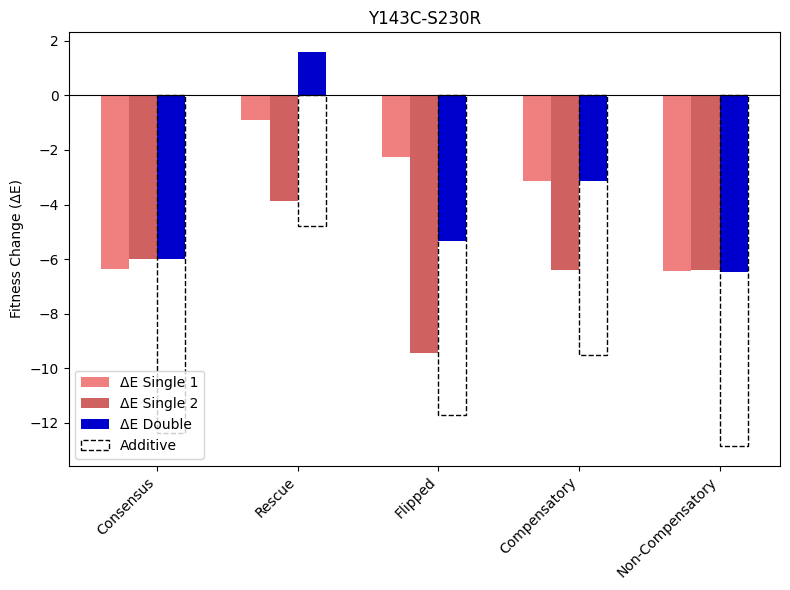

In [51]:
# IN_pair = 'G140S-Q148H'
IN_pair = 'Y143C-S230R'
# IN_pair = 'G140A-Q148K'
# IN_pair = 'G140S-Q148R'
# IN_pair = 'G140S-Q148K'
pair1, pair2 = functions.split_pairs(IN_pair)
p1_reduced = functions.unreduced_to_reduced(IN_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(IN_redux, pair2)

IN_bars = []
IN_rescue_bars = []
IN_flipped_bars = []
IN_compensatory_bars = []
IN_other_bars = []

consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_consensus_seq, IN_J, 1, 263)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for IN_seq in IN_all_seq:
    # Debugging: Print inputs to the function

    result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_seq, IN_J, 1, 263)
    
    # Check if the result is None
    if result is None:
        # print(f"Warning: result is None for sequence {IN_all_seq.index(IN_seq)}")
        continue  # Skip this sequence
    
    pair1_de, pair2_de, pair12_de, pair12_dde = result
    if (pair1_de - pair2_de)*consensus_flip_relation < 0:
        IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
    
    if pair1_de < pair12_de and pair2_de < pair12_de:
        IN_rescue_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
    elif pair1_de < pair12_de or pair2_de < pair12_de:
        IN_compensatory_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
    
    else:
        IN_other_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))

IN_rescue_bars.sort(key=lambda x: x[3], reverse=True)
IN_flipped_bars.sort(key=lambda x: abs(x[1]-x[2]), reverse=True)
IN_compensatory_bars.sort(key=lambda x: x[3], reverse=True)
IN_other_bars.sort(key=lambda x: x[3], reverse=True)

IN_bars.insert(0, ('Consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
# print("IN_bars:", IN_bars)

IN_bars.insert(1, ('Rescue', IN_rescue_bars[0][1], IN_rescue_bars[0][2], IN_rescue_bars[0][3]))
IN_bars.insert(2, ('Flipped', IN_flipped_bars[0][1], IN_flipped_bars[0][2], IN_flipped_bars[0][3]))
IN_bars.insert(3, ('Compensatory', IN_compensatory_bars[0][1], IN_compensatory_bars[0][2], IN_compensatory_bars[0][3]))
IN_bars.insert(4, ('Non-Compensatory', IN_other_bars[0][1], IN_other_bars[0][2], IN_other_bars[0][3]))
plot.plot_epistatic_bar(IN_pair,IN_bars[:5])

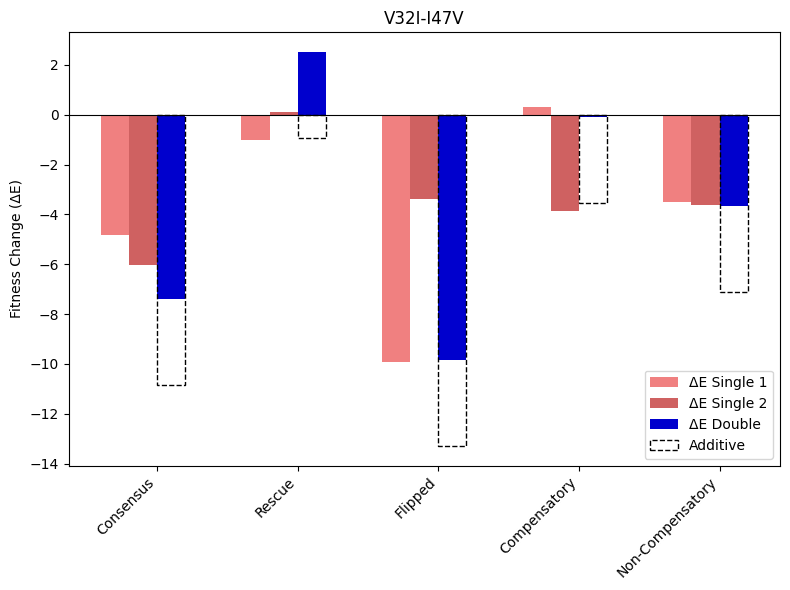

In [52]:
# PR_pair = 'D30N-N88D'
PR_pair = 'V32I-I47V'
# PR_pair = 'G48V-I54A'
# PR_pair = 'D30N-K45Q'
# PR_pair = 'I54A-V82A'

pair1, pair2 = functions.split_pairs(PR_pair)
p1_reduced = functions.unreduced_to_reduced(PR_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(PR_redux, pair2)

PR_bars = []
PR_rescue_bars = []
PR_flipped_bars = []
PR_compensatory_bars = []
PR_other_bars = []

consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_consensus_seq, PR_J, 1, 99)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for PR_seq in PR_all_seq:
    # Debugging: Print inputs to the function

    result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_seq, PR_J, 1, 99)
    
    # Check if the result is None
    if result is None:
        # print(f"Warning: result is None for sequence {IN_all_seq.index(IN_seq)}")
        continue  # Skip this sequence
    
    pair1_de, pair2_de, pair12_de, pair12_dde = result
    if (pair1_de - pair2_de)*consensus_flip_relation < 0:
        PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
    
    if pair1_de < pair12_de and pair2_de < pair12_de:
        PR_rescue_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
    elif pair1_de < pair12_de or pair2_de < pair12_de:
        PR_compensatory_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
    
    else:
        PR_other_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))

    # PR_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))

PR_rescue_bars.sort(key=lambda x: x[3], reverse=True)
PR_flipped_bars.sort(key=lambda x: abs(x[1]-x[2]), reverse=True)
PR_compensatory_bars.sort(key=lambda x: x[3], reverse=True)
PR_other_bars.sort(key=lambda x: x[3], reverse=True)

# PR_bars.sort(key=lambda x: x[3], reverse=True)
PR_bars.insert(0, ('Consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
# print("IN_bars:", IN_bars)

PR_bars.insert(1, ('Rescue', PR_rescue_bars[0][1], PR_rescue_bars[0][2], PR_rescue_bars[0][3]))
PR_bars.insert(2, ('Flipped', PR_flipped_bars[0][1], PR_flipped_bars[0][2], PR_flipped_bars[0][3]))
PR_bars.insert(3, ('Compensatory', PR_compensatory_bars[0][1], PR_compensatory_bars[0][2], PR_compensatory_bars[0][3]))
PR_bars.insert(4, ('Non-Compensatory', PR_other_bars[0][1], PR_other_bars[0][2], PR_other_bars[0][3]))
plot.plot_epistatic_bar(PR_pair, PR_bars[:5])

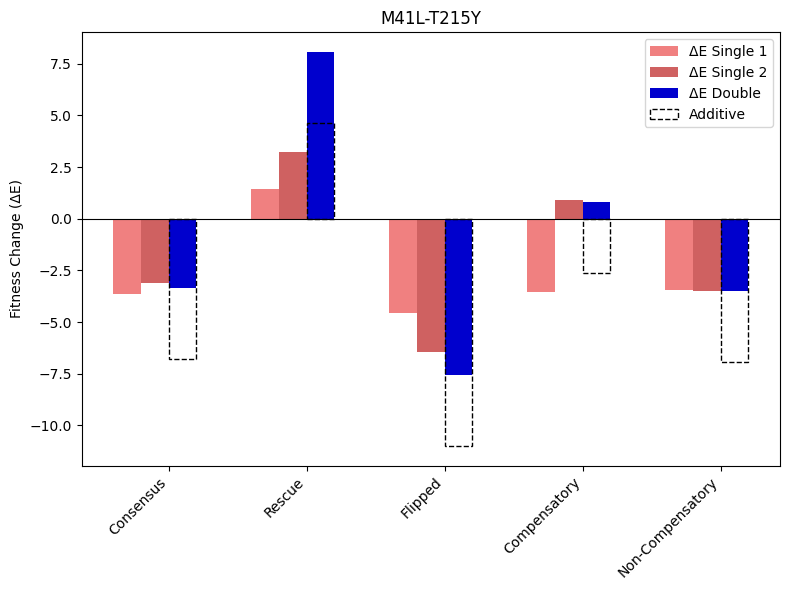

In [54]:
# RT_pair = 'F116Y-Q151M'
RT_pair = 'M41L-T215Y'

pair1, pair2 = functions.split_pairs(RT_pair)
p1_reduced = functions.unreduced_to_reduced(RT_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(RT_redux, pair2)

RT_bars = []
RT_rescue_bars = []
RT_flipped_bars = []
RT_compensatory_bars = []
RT_other_bars = []

consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, RT_consensus_seq, RT_J, 39, 226)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for RT_seq in RT_all_seq:
    result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, RT_seq, RT_J, 39, 226)
    
    if result is None:
        continue
    
    pair1_de, pair2_de, pair12_de, pair12_dde = result
    if (pair1_de - pair2_de) * consensus_flip_relation < 0:
        RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
    
    if pair1_de < pair12_de and pair2_de < pair12_de:
        RT_rescue_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
    elif pair1_de < pair12_de or pair2_de < pair12_de:
        RT_compensatory_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
    else:
        RT_other_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))

RT_rescue_bars.sort(key=lambda x: x[3], reverse=True)
RT_flipped_bars.sort(key=lambda x: abs(x[1] - x[2]), reverse=True)
RT_compensatory_bars.sort(key=lambda x: x[3], reverse=True)
RT_other_bars.sort(key=lambda x: x[3], reverse=True)

RT_bars.insert(0, ('Consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
RT_bars.insert(1, ('Rescue', RT_rescue_bars[0][1], RT_rescue_bars[0][2], RT_rescue_bars[0][3]))
RT_bars.insert(2, ('Flipped', RT_flipped_bars[0][1], RT_flipped_bars[0][2], RT_flipped_bars[0][3]))
RT_bars.insert(3, ('Compensatory', RT_compensatory_bars[0][1], RT_compensatory_bars[0][2], RT_compensatory_bars[0][3]))
RT_bars.insert(4, ('Non-Compensatory', RT_other_bars[0][1], RT_other_bars[0][2], RT_other_bars[0][3]))
plot.plot_epistatic_bar(RT_pair, RT_bars[:5])